In [100]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline




In [101]:
df = pd.read_csv('Algerian_forestFire_cleaned_dataset.csv')


In [102]:
print(df.head())
print(df.columns)

   day  month  year  Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  \
0    1      6  2012           29  57  18   0.0  65.7  3.4   7.6  1.3  3.4   
1    2      6  2012           29  61  13   1.3  64.4  4.1   7.6  1.0  3.9   
2    3      6  2012           26  82  22  13.1  47.1  2.5   7.1  0.3  2.7   
3    4      6  2012           25  89  13   2.5  28.6  1.3   6.9  0.0  1.7   
4    5      6  2012           27  77  16   0.0  64.8  3.0  14.2  1.2  3.9   

   FWI      Classes  Region  
0  0.5  not fire          0  
1  0.4  not fire          0  
2  0.1  not fire          0  
3  0.0  not fire          0  
4  0.5  not fire          0  
Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')


In [103]:
df.drop(['day', 'month', 'year'], axis =1, inplace=True) ##axis to remove all days,month,year

In [104]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [105]:
df["Classes"] = df["Classes"].str.strip()

df["Classes"] = df["Classes"].map({
    "not fire": 0,
    "fire": 1
})

In [106]:
print(df["Classes"].dtype)
print(df["Classes"].head())

int64
0    0
1    0
2    0
3    0
4    0
Name: Classes, dtype: int64


In [107]:
##dependent and independent features
X = df.drop(['FWI','BUI'], axis=1)
y = df['FWI']

In [108]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,0,0


In [109]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [110]:
##Train test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42 )

In [111]:
X_train.shape,X_test.shape

((182, 10), (61, 10))

<Axes: >

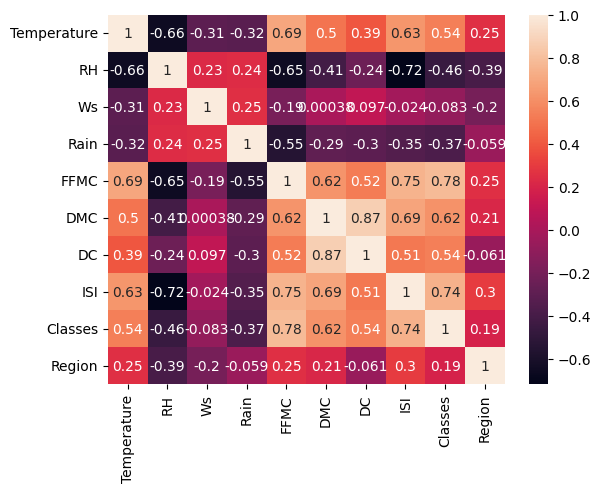

In [112]:
##Feature selection based on correlation
sns.heatmap(X_train.corr(), annot =True)

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [114]:
print(X_train.dtypes)

Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
Classes          int64
Region           int64
dtype: object


In [115]:
Threshold = 0.95
dataset = X_train
corr_features = col(dataset, Threshold)
print(corr_features)

set()


In [116]:
##removing highly correlated features using threshold value
def col(dataset, Threshold):
    col_corr= set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]> Threshold):
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
            
    return col_corr




In [117]:
X_train.drop(corr_features, axis =1, inplace = True)
X_test.drop(corr_features, axis =1, inplace = True)
X_train.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,Classes,Region
97,29,74,19,0.1,75.8,3.6,32.2,2.1,0,0
141,31,72,14,0.2,60.2,3.8,8.0,0.8,0,1
192,40,31,15,0.0,94.2,22.5,46.3,16.6,1,1
68,32,60,18,0.3,77.1,11.3,47.0,2.2,0,0
119,32,47,14,0.7,77.5,7.1,8.8,1.8,0,0


In [118]:
##feature scaling or Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled.shape


 

(61, 10)

In [119]:
print(X_train.columns.tolist())
print(X_test.columns.tolist())

print(X_train.columns.equals(X_test.columns))

['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'Classes', 'Region']
['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'Classes', 'Region']
True


In [120]:
X_test = X_test[X_train.columns]

<Axes: >

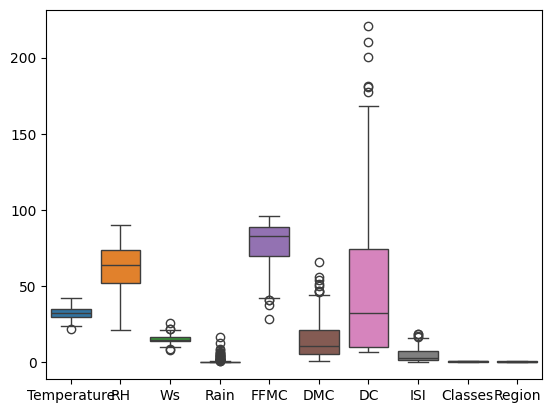

In [121]:
sns.boxplot(data = X_train)




<Axes: >

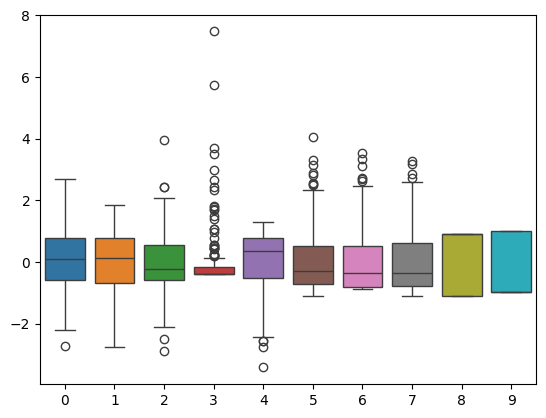

In [122]:
sns.boxplot(data = X_train_scaled )

In [123]:
##linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred= linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error ", mae)
print("r2_score ", score)


mean absolute error  0.5170107980662408
r2_score  0.9830565611009445


mean absolute error  0.5292519766274832
r2_score  0.9824051915524249


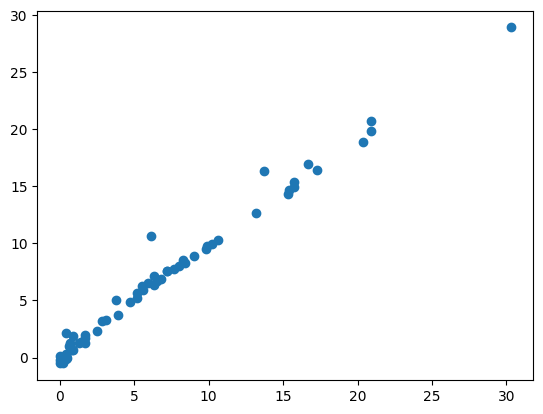

In [124]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred= ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error ", mae)
print("r2_score ", score)
plt.scatter(y_test,y_pred)

mean absolute error  1.1257992990774721
r2_score  0.9498931628519823


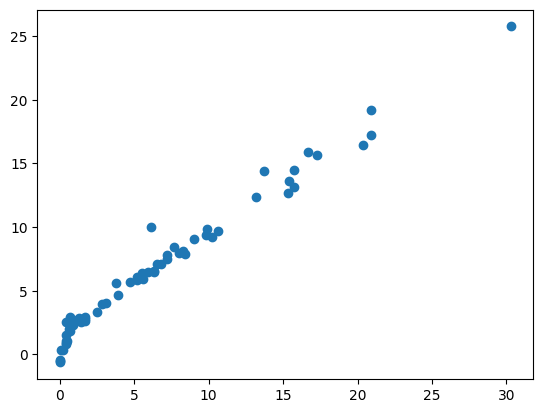

In [125]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred= lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error ", mae)
print("r2_score ", score)
plt.scatter(y_test,y_pred)

mean absolute error  1.7704255521425294
r2_score  0.8887824924177792


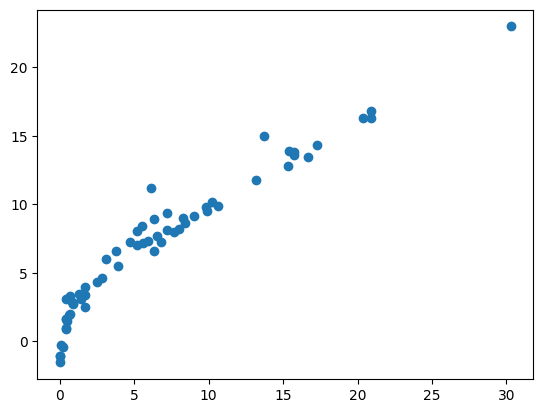

In [126]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
en = ElasticNet()
en.fit(X_train_scaled, y_train)
y_pred= en.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error ", mae)
print("r2_score ", score)
plt.scatter(y_test,y_pred)

mean absolute error  0.5292519766274832
r2_score  0.9824051915524249


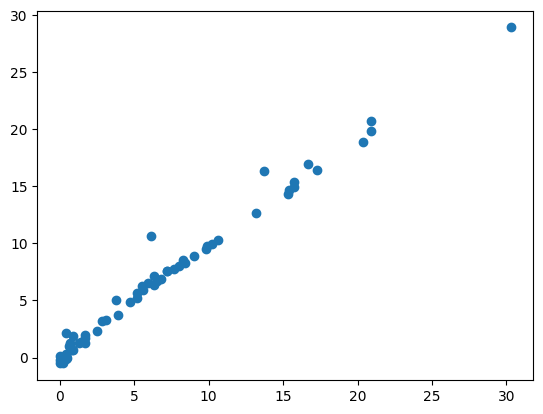

In [127]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=10)
ridgecv.fit(X_train_scaled, y_train)
y_pred= ridgecv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score = r2_score(y_test,y_pred)
print("mean absolute error ", mae)
print("r2_score ", score)
plt.scatter(y_test,y_pred)


In [128]:
##pickle the machine learning model, preprocessing model standard scaler
import pickle
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))